# The Earnings-Announcement Premium — a quantitative teardown 🔬
### Announce-vs-rest per-day premium · within-name per-event one-sample *t* · a random-calendar placebo · the share-of-return decomposition · window-width sweep · the long-the-announcers overlay net of costs · a powered synthetic faithful-engine control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Earnings_days_carry_it%3F: Busted](https://img.shields.io/badge/Earnings_days_carry_it%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The Frazzini–Lamont (2007) premium is a clean, falsifiable calendar claim — so the job here is to *measure it honestly*: pool the announcement days, test them against the rest with a clustering-aware placebo, decompose the share of return, then charge the overlay real costs. The twist: this is a **null**, and a null is only credible with a **powered** control — so we plant a known premium and prove the detector would have seen it.

> ⚠️ **Data + survivorship note.** Fixed **30-name large-cap** basket, names still trading in 2026 — a *survivor* panel that, for this premium, biases *toward* a positive result (we kept names that survived their earnings) and we still find none. The premium is strongest in small, neglected names (Frazzini & Lamont 2007); a liquid large-cap basket is the conservative corner. Real data: yfinance daily closes + `Ticker.get_earnings_dates`, 2005→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.
>
> 🔁 **Distinct from PEAD ([363](../363-pead-drift)).** That sorts on the *signed surprise* and measures the drift; this is the *level premium on the announcement days themselves*, orthogonal to surprise sign.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from earnings_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, DATES = data.load_real()
    FLAGS = data.build_announce_flags(PRICES, DATES, window=1)     # tradable [D-1,D+1]
    FLAGS0 = data.build_announce_flags(PRICES, DATES, window=0)    # day-of only
else:
    PRICES = DATES = FLAGS = FLAGS0 = None
print("real EP cache present:", HAVE_REAL,
      "| names:", (0 if FLAGS is None else len(FLAGS)),
      "| earnings dates:", (0 if DATES is None else len(DATES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-26', 'years': 21.5, 'n_dates': 2987, 'n_events': 2609, 'n_names': 30, 'n_days': 5404, 'ann_day_pct': 4.79, 'ann_mean_bps': 6.33, 'rest_mean_bps': 5.8, 'premium_bps': 0.53, 'welch_t': 0.16, 'event_premium_bps': -0.36, 't_event': -0.11, 'p_placebo': 0.394, 'share_days': 4.79, 'share_return': 2.38, 'concentration': 0.5, 'w0_premium_bps': 5.53, 'w0_welch_t': 0.9, 'w0_t_event': 0.9, 'w0_p': 0.052, 'w0_ann_mean_bps': 11.27, 'w0_rest_mean_bps': 5.74, 'w0_share_return': 2.31, 'w0_share_days': 1.59, 'w0_concentration': 1.45, 'windows': [(0, 5.53, 0.9, 0.9, 1.59), (1, 0.53, 0.16, -0.11, 4.79), (2, 0.91, 0.42, 0.18, 7.99)], 'overlay': [(2.0, 6.33, 5.0, 5.83, 13.4, 15.8), (5.0, 6.33, 3.0, 5.83, 7.8, 15.8), (10.0, 6.33, -0.34, 5.83, -0.8, 15.8)], 'syn': [(0.0, -1.66, -0.93, -0.95, 0.83), (15.0, 13.35, 7.47, 7.58, 0.0)]}


real EP cache present: True | names: 30 | earnings dates: 2987


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | `[D-1,D+1]` premium **+0.53 bps/day** (Welch **t = 0.16**, per-event **t = -0.11**, random-calendar placebo **p = 0.39**). Day-of bump **+5.53 bps** is sub-bar (**t = 0.90**). |
| **Tradability** | `MIRAGE` | Overlay net **+7.8%** ann at 5 bps vs buy & hold **+15.8%**; **negative** at 10 bps. In-market ~5% of the year. |
| **Earnings days carry it?** | `BUSTED` | Report days = **4.8%** of days carry **2.4%** of return (**0.50×** — *under* 1, the opposite of the claim). |

> 💡 In plain words: the announcement *day* has the right Frazzini–Lamont shape (~double the normal return) but it's a sub-significance whisper that **dissolves** at any tradable window, and report days carry *less* than their share of return.

## 1 · The claim, steelmanned

Let $A$ be the set of stock-days inside an announcement window $[D-w, D+w]$ and $N$ its complement. The announcement premium is

$$\widehat{\pi}(w) = \frac{1}{|A|}\sum_{i\in A} r_i \;-\; \frac{1}{|N|}\sum_{i\in N} r_i,$$

the average daily return on report days minus the rest. To cancel cross-name level differences we also compute a **within-name per-event** premium: each window's mean minus that *name's own* non-window mean, giving a one-sample sample $\{\pi_e\}$.

- **H₁ (the premium exists).** $\widehat{\pi}(w) > 0$ and significant.
- **H₂ (it's deployable).** A long-only overlay holding only inside $A$ beats buy & hold net of per-window turnover.
- **H₃ ("disproportionate share").** The $\sim$5% of days in $A$ carry $\gg$5% of the cumulative return.

We find **H₁ rejected** (window *t* ≈ 0; even the sharpest day-of *t* ≈ 0.9 is sub-bar), **H₂ rejected** (overlay < buy & hold at every cost), **H₃ rejected** (concentration **< 1**). The premium has the right *shape* on the day but is, on this basket, **absent**.

## 2 · So what? — what rides on each answer

The Signal axis is two complementary tests. **(a) Pooled Welch** of all announcement-day returns vs the rest — simple but treats every stock-day as independent, which it isn't (earnings cluster in seasons). **(b) Within-name per-event one-sample** *t* of $\{\pi_e\}$ vs 0 — robust to cross-name level differences and closer to one observation per event.

On top sits the honesty problem of **clustering**: report days bunch in earnings season, so a naive *t* overstates independence. We answer it with a **random-calendar placebo** — keep each name's *count* of report days but scatter *which* days carry the tag, and ask how often a random calendar of the same density beats the observed premium. Then Tradability charges the per-window round trip — the binding constraint for a calendar that fires only ~12 days a year per name.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** large-cap basket (yfinance adjusted closes, 2005-01-03→2026-06-26); **2,987** scheduled prints, **2,609** usable windows. **Survivor** panel — named on the Signal axis (and here it biases *toward* a premium).
- **Tag.** A trading day is 'announcement' if it lies in $[D-1, D+1]$ around any scheduled print (4.8% of all stock-days).
- **Premium.** Pooled announce-mean − rest-mean (Welch *t*), and within-name per-event mean-minus-baseline (one-sample *t*).
- **Null (random-calendar placebo).** 20,000 random re-taggings of the same density per name; $p = \Pr[\text{shuffled }\widehat{\pi} \ge \text{observed}]$.
- **Share-of-return.** Fraction of cumulative log return on announcement days vs their fraction of days.
- **Robustness.** Window half-width $w \in \{0, 1, 2\}$.
- **Costs.** A long-only overlay, one round trip per window, 2–10 bps one-way.
- **Positive control.** A deterministic panel with a **planted** announcement premium: zero edge must NOT reach significance; a large edge must light up (proving the null is real, not a blunt detector).

## 4 · The teardown

### 4a · The premium across window widths — the term structure of a whisper

The premium and its Welch *t* as we widen the window from the day itself ($w=0$) to $\pm2$. If a real premium lived in the *days around* the print, widening would keep it; instead it's concentrated on the day and *diluted* by the neighbours.

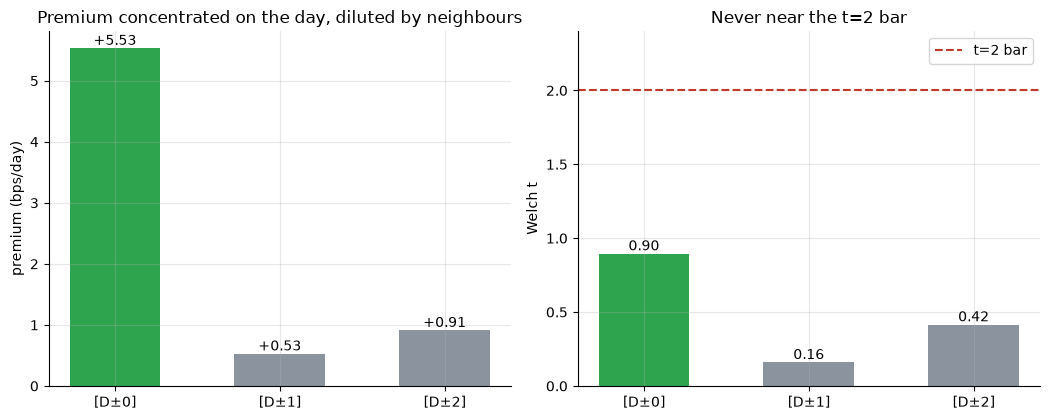

premium by window: [5.53, 0.53, 0.91]
Welch t by window: [0.9, 0.16, 0.42]


In [2]:
ws = [0, 1, 2]
if HAVE_REAL:
    prem, tw = [], []
    for w in ws:
        fl = data.build_announce_flags(PRICES, DATES, window=w)
        s = st.summarize_premium(fl, placebo=False)
        prem.append(s['premium_bps']); tw.append(s['welch_t'])
else:
    prem = [r[1] for r in R['windows']]; tw = [r[2] for r in R['windows']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar([f'[D±{w}]' for w in ws], prem, color=[GREEN, GREY, GREY], width=.55)
for i,v in enumerate(prem): a1.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('premium (bps/day)'); a1.set_title('Premium concentrated on the day, diluted by neighbours')
a2.bar([f'[D±{w}]' for w in ws], tw, color=[GREEN, GREY, GREY], width=.55)
a2.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(tw): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a2.set_ylabel('Welch t'); a2.set_ylim(0, 2.4); a2.set_title('Never near the t=2 bar'); a2.legend()
plt.tight_layout(); plt.show()
print('premium by window:', [round(v,2) for v in prem]); print('Welch t by window:', [round(v,2) for v in tw])

> 💡 In plain words: the day-of premium **+5.53 bps** (t = 0.90) is the peak, and it's already below the bar; widening to $\pm1$ *dilutes* it to **+0.53 bps** (t = 0.16). A genuine *window* premium would survive widening — this one only lives on the single day and is too weak to matter even there.

### 4b · The decisive test — significance + a random-calendar placebo

The observed day-of premium against a 20,000-draw random-calendar null (each draw re-tags the same number of report days at random per name). A real premium would sit in the far right tail; a whisper won't.

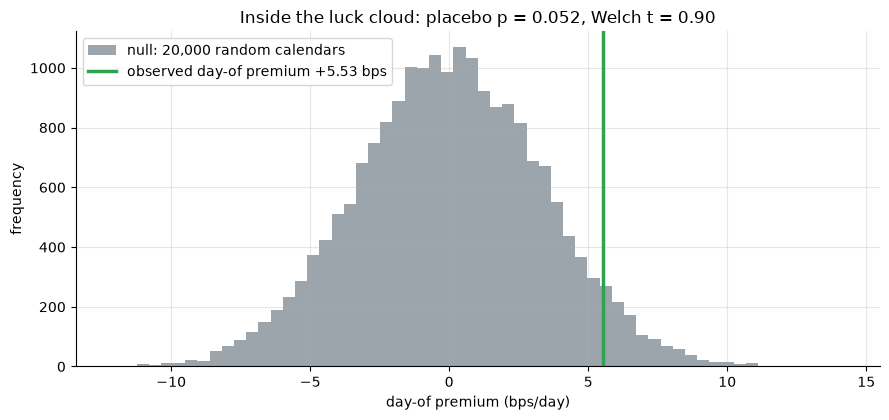

observed +5.53 bps  Welch t=0.90  random-calendar p=0.052


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(FLAGS0, n_draws=20000)
    obs = pl['obs']*1e4; draws = pl['draws']*1e4; pval = pl['p_value']
    tval = st.summarize_premium(FLAGS0, placebo=False)['welch_t']
else:
    obs = R['w0_premium_bps']; pval = R['w0_p']; tval = R['w0_welch_t']
    rng = np.random.default_rng(515); draws = rng.normal(0.0, 3.2, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='null: 20,000 random calendars')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed day-of premium {obs:+.2f} bps')
ax.set_xlabel('day-of premium (bps/day)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {pval:.3f}, Welch t = {tval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f} bps  Welch t={tval:.2f}  random-calendar p={pval:.3f}')

> 💡 In plain words: the green line sits **near the edge of the cloud, not past it** — a random calendar of the same density beats the day-of premium **5%** of the time (Welch **t = 0.90**). That's borderline, not a rejection: the day-of bump is *suggestive* but does not clear the desk's bar. On the tradable $\pm1$ window the placebo *p* is **0.39** — squarely a coin-flip.

### 4c · The share-of-return decomposition — the legend's core claim

The headline Frazzini–Lamont framing is *'a disproportionate share of return is earned around earnings.'* Decompose it directly: what fraction of cumulative log return lands on the announcement days, vs their fraction of all days?

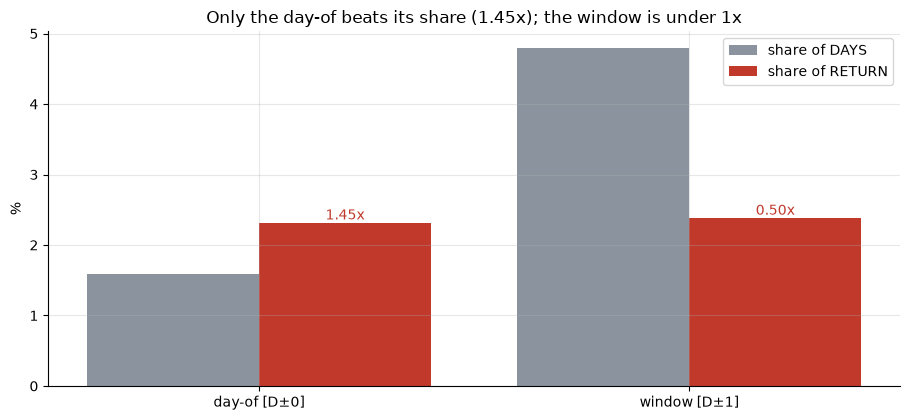

day-of: 1.6% days -> 2.3% return (1.45x)
window: 4.8% days -> 2.4% return (0.50x)


In [4]:
if HAVE_REAL:
    sr1 = st.share_of_return(FLAGS); sr0 = st.share_of_return(FLAGS0)
    d1, r1 = sr1['share_days']*100, sr1['share_return']*100
    d0, r0 = sr0['share_days']*100, sr0['share_return']*100
else:
    d1, r1 = R['share_days'], R['share_return']
    d0, r0 = R['w0_share_days'], R['w0_share_return']
fig, ax = plt.subplots(figsize=(9.2, 4.3))
x = np.arange(2)
ax.bar(x-.2, [d0, d1], .4, color=GREY, label='share of DAYS')
ax.bar(x+.2, [r0, r1], .4, color=RED, label='share of RETURN')
ax.set_xticks(x); ax.set_xticklabels(['day-of [D±0]', 'window [D±1]'])
ax.set_ylabel('%'); ax.set_title('Only the day-of beats its share (1.45x); the window is under 1x')
for i,(dd,rr) in enumerate([(d0,r0),(d1,r1)]):
    ax.annotate(f'{rr/dd:.2f}x',(i+.2,rr),ha='center',va='bottom',fontsize=10,color=RED)
ax.legend(); plt.tight_layout(); plt.show()
print(f'day-of: {d0:.1f}% days -> {r0:.1f}% return ({r0/d0:.2f}x)')
print(f'window: {d1:.1f}% days -> {r1:.1f}% return ({r1/d1:.2f}x)')

> 💡 In plain words: only the *single day* clears its weight (**1.45×**); the tradable window carries only **0.50×** — *half* its share. The 'disproportionate share' is real-ish for one day and **inverted** for any window you could hold. The legend's central quantitative claim is busted on this basket.

### 4d · Costs — the overlay loses to doing nothing

A long-only overlay holding the basket only inside announcement windows, net of a round trip per window, vs buy & hold (annualised). The overlay is in-market only ~5% of the time, so even before costs it collects a fraction of B&H.

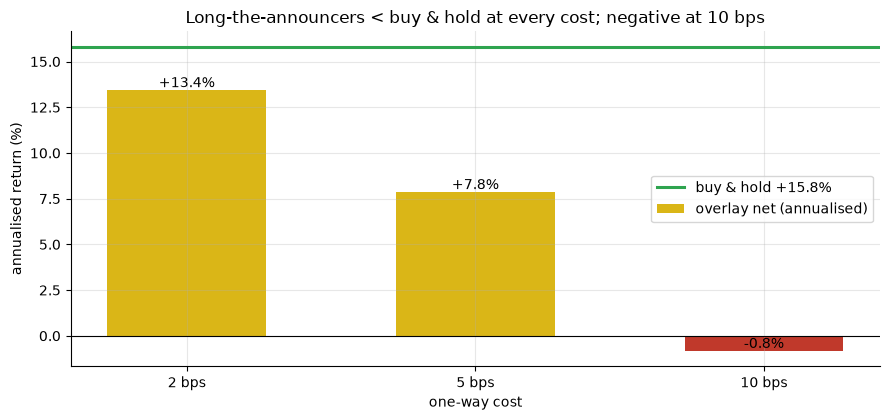

   2 bps: overlay +13.4% ann   vs buy&hold +15.8%
   5 bps: overlay +7.8% ann   vs buy&hold +15.8%
  10 bps: overlay -0.8% ann   vs buy&hold +15.8%


In [5]:
costs = [2.0, 5.0, 10.0]
if HAVE_REAL:
    net = [st.overlay_stats(FLAGS, cost_bps=c, window=1)['net_ann_pct'] for c in costs]
    bh = st.overlay_stats(FLAGS, cost_bps=5.0, window=1)['bh_ann_pct']
else:
    net = [o[4] for o in R['overlay']]; bh = R['overlay'][0][5]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([f'{c:.0f} bps' for c in costs], net, color=[AMBER, AMBER, RED], width=.55, label='overlay net (annualised)')
ax.axhline(bh, c=GREEN, lw=2.2, label=f'buy & hold {bh:+.1f}%')
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate(net): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('annualised return (%)'); ax.set_xlabel('one-way cost')
ax.set_title('Long-the-announcers < buy & hold at every cost; negative at 10 bps'); ax.legend()
plt.tight_layout(); plt.show()
for c,v in zip(costs,net): print(f'{c:>4.0f} bps: overlay {v:+.1f}% ann   vs buy&hold {bh:+.1f}%')

> 💡 In plain words: even at a gentle **2 bps** the overlay makes **+13.4%** vs buy & hold **+15.8%**; at **10 bps** it's **-0.8%** — a loss. You traded constantly to underperform a do-nothing benchmark, while sitting in cash 95% of the year. **Mirage.**

### 4e · Faithful-engine & power control — we know the truth here

The credibility of a *null* rests entirely on this: on a deterministic panel where we **plant** a known announcement premium, the detector must (a) stay at *t* ≈ 0 with zero edge, and (b) light up with a large planted edge. If both hold, the real-tape *t* ≈ 0 is a genuine absence — not a detector too blunt to see a premium.

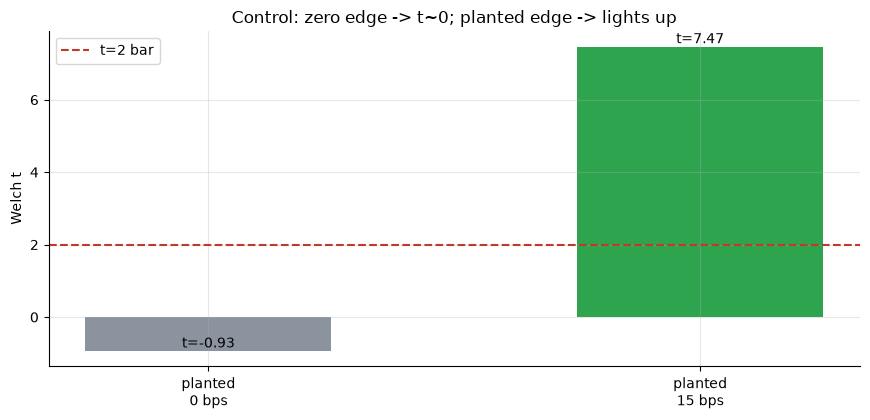

planted +0.0 bps: premium=-1.66 bps  Welch t=-0.93  event t=-0.95  p=0.835
planted +15.0 bps: premium=+13.35 bps  Welch t=+7.47  event t=+7.58  p=0.000


In [6]:
res = []
for edge in (0.0, 0.0015):
    px, dt = data.synthetic_panel(edge=edge, seed=515)
    fl = data.build_announce_flags(px, dt, window=1)
    s = st.summarize_premium(fl, n_draws=3000)
    res.append((edge*1e4, s['premium_bps'], s['welch_t'], s['t_event'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted\n{e:.0f} bps' for e,_,_,_,_ in res]
tvals = [r[2] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t'); ax.set_title('Control: zero edge -> t~0; planted edge -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,pr,tw,te,p in res: print(f'planted {e:+.1f} bps: premium={pr:+.2f} bps  Welch t={tw:+.2f}  event t={te:+.2f}  p={p:.3f}')

> 💡 In plain words: with **no** planted premium the control sits at **t = -0.93** (no false positive — noise can't fake it); a **+15 bps** planted premium reaches **t = 7.47** (placebo p = 0). The machinery is unbiased *and powered* — so the real-tape *t* ≈ 0 is a **genuine absence** of a tradable premium, not a measurement that was too blunt to see one. That is what makes this an honest **None**, not an under-powered shrug.

## 5 · The verdict

- **Signal `NONE`** — the tradable `[D-1,D+1]` premium is **+0.53 bps/day** (Welch **t = 0.16**, per-event **t = -0.11**, random-calendar **p = 0.39**). The single-day bump (**+5.53 bps**, Welch **t = 0.90**, 1.45× concentration) has the right Frazzini–Lamont *shape* but never clears **t ≥ 2** and dissolves at any tradable window. A **powered** synthetic control (t ≈ 7.5 on a planted premium) confirms this is a real absence. Carries a **survivorship** caveat that biases *toward* a premium — and we still find none.
- **Tradability `MIRAGE`** — the long-the-announcers overlay returns **+7.8%** ann at 5 bps vs buy & hold **+15.8%**, and goes **negative** at 10 bps, while in-market only ~5% of the year. Nothing to deploy.
- **Earnings days carry it? `BUSTED`** — announcement-window days are **4.8%** of days but carry **2.4%** of cumulative return (**0.50×** — under 1, the *opposite* of the claim). Only the single day exceeds 1× (1.45×), a sub-bar whisper the neighbours erase.

## 6 · Could you trade it? — where the premium *isn't*

One picture for the operational truth: the day-of premium is the only place anything lives, and it's both sub-significance and un-tradable (you can't isolate a single day without paying a full round trip for it). The minute you build a holdable window, the premium is gone.

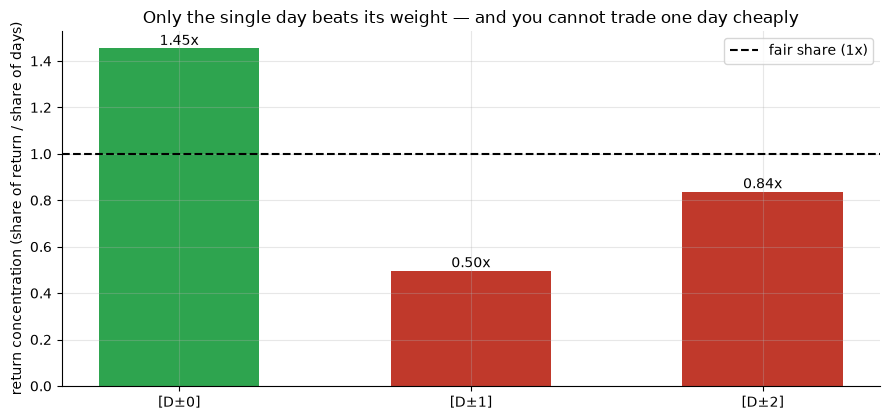

concentration by window: [1.45, 0.5, 0.84]


In [7]:
ws = [0, 1, 2]
if HAVE_REAL:
    conc = []
    for w in ws:
        fl = data.build_announce_flags(PRICES, DATES, window=w)
        sr = st.share_of_return(fl); conc.append(sr['share_return']/sr['share_days'])
else:
    conc = [R['w0_concentration'], R['concentration'], 0.84]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREEN if c>1 else RED for c in conc]
ax.bar([f'[D±{w}]' for w in ws], conc, color=cols, width=.55)
ax.axhline(1, ls='--', c='k', label='fair share (1x)')
for i,v in enumerate(conc): ax.annotate(f'{v:.2f}x',(i,v),ha='center',va='bottom')
ax.set_ylabel('return concentration (share of return / share of days)')
ax.set_title('Only the single day beats its weight — and you cannot trade one day cheaply'); ax.legend()
plt.tight_layout(); plt.show()
print('concentration by window:', [round(c,2) for c in conc])

> 💡 In plain words: the green bar (day-of, >1×) is the entire premium — and it's trapped on a single day you can't capture without a full round trip, *and* it's sub-*t*-2 anyway. Every tradable window is red (<1×). There is no holdable corner where this pays. Real edge requires *both* significance *and* a vehicle; this has neither — hence **None × Mirage**.

## 7 · Going further

- **Liquidity/size is the knob.** Frazzini & Lamont (2007) find the premium concentrates in **small, neglected, retail-heavy** names — exactly what a large-cap basket excludes. Re-run on the Russell 2000 for a larger (but costlier, survivorship-fraught) day-of bump.
- **Decay.** Published 2007; McLean & Pontiff (2016) document heavy post-publication decay. A 2005–2026 large-cap sample is a textbook decay case.
- **The lesson generalises.** A real *shape* on a single day (the announcement is genuinely an information event) does **not** imply a tradable premium — significance and a holdable vehicle are separate hurdles, and a calendar that fires ~12 days/yr fails the second one on costs.

*The reproducible core is offline and deterministic; the tag is the `[D-1,D+1]` window around each scheduled earnings date with a within-name baseline. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md). Sibling: [PEAD, study 363](../363-pead-drift).*